# NB02: Resistome vs Environment (Species-Level)

Test H1 (AMR diversity differs by environment), H2 (core vs accessory by niche),
H3 (mechanism enrichment by environment).

**Key design choices from review:**
- Family-level phylogenetic control (not phylum)
- Effect sizes (eta-squared) alongside p-values
- BH-FDR correction within each test family
- Sensitivity analysis at multiple majority thresholds

**Inputs:** `data/species_amr_profiles.csv`

**Outputs:** `data/environment_amr_comparison.csv`, figures

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_environmental_resistome')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_environmental_resistome')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

sp = pd.read_csv(os.path.join(DATA, 'species_amr_profiles.csv'))
sp['no_genomes'] = pd.to_numeric(sp['no_genomes'], errors='coerce')

# Filter to species with environment data
sp_env = sp[sp['species_environment'].notna()].copy()
print(f'Species with AMR + environment: {len(sp_env):,}')
print(f'Environments: {sp_env["species_environment"].value_counts().to_dict()}')

Species with AMR + environment: 13,981
Environments: {'host_associated': 4788, 'other_environmental': 3195, 'aquatic': 2543, 'soil': 1905, 'clinical': 1186, 'human_gut': 364}


## 1. H1: AMR diversity across environments

In [2]:
# Kruskal-Wallis: total AMR clusters by environment
envs = ['clinical', 'human_gut', 'host_associated', 'soil', 'aquatic', 'other_environmental']
groups = [sp_env[sp_env['species_environment'] == e]['n_amr_clusters'].values for e in envs]

kw_stat, kw_p = stats.kruskal(*groups)

# Effect size: eta-squared = (H - k + 1) / (n - k)
n_total = len(sp_env)
k = len(envs)
eta_sq = (kw_stat - k + 1) / (n_total - k)

print('=== H1: AMR diversity by environment ===')
print(f'Kruskal-Wallis: H={kw_stat:.1f}, p={kw_p:.4g}, eta²={eta_sq:.4f}')
print()

for env in envs:
    sub = sp_env[sp_env['species_environment'] == env]
    print(f'  {env:25s}: N={len(sub):5,}, median AMR={sub["n_amr_clusters"].median():4.0f}, '
          f'mean={sub["n_amr_clusters"].mean():5.1f}, IQR=[{sub["n_amr_clusters"].quantile(0.25):.0f}-'
          f'{sub["n_amr_clusters"].quantile(0.75):.0f}]')

=== H1: AMR diversity by environment ===
Kruskal-Wallis: H=781.9, p=9.446e-167, eta²=0.0556

  clinical                 : N=1,186, median AMR=   5, mean= 18.7, IQR=[2-11]
  human_gut                : N=  364, median AMR=   5, mean=  9.6, IQR=[2-10]
  host_associated          : N=4,788, median AMR=   2, mean=  5.1, IQR=[1-5]
  soil                     : N=1,905, median AMR=   2, mean=  4.1, IQR=[1-5]
  aquatic                  : N=2,543, median AMR=   2, mean=  3.4, IQR=[1-3]
  other_environmental      : N=3,195, median AMR=   2, mean=  4.4, IQR=[1-5]


In [3]:
# Pairwise Mann-Whitney U between environments (BH-FDR)
from itertools import combinations

pairwise = []
for e1, e2 in combinations(envs, 2):
    g1 = sp_env[sp_env['species_environment'] == e1]['n_amr_clusters']
    g2 = sp_env[sp_env['species_environment'] == e2]['n_amr_clusters']
    u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    # Effect size: rank-biserial r = 1 - 2U/(n1*n2)
    r_rb = 1 - 2 * u / (len(g1) * len(g2))
    pairwise.append({'env1': e1, 'env2': e2, 'U': u, 'p_value': p,
                     'rank_biserial_r': r_rb,
                     'median1': g1.median(), 'median2': g2.median()})

pw_df = pd.DataFrame(pairwise)
_, q, _, _ = multipletests(pw_df['p_value'], method='fdr_bh')
pw_df['q_value'] = q
pw_df['significant'] = q < 0.05

print(f'Pairwise comparisons: {len(pw_df)}, significant: {pw_df["significant"].sum()}')
print()
for _, row in pw_df.sort_values('q_value').head(10).iterrows():
    sig = '*' if row['significant'] else ''
    print(f'  {row["env1"]:20s} vs {row["env2"]:20s}: '
          f'med {row["median1"]:.0f} vs {row["median2"]:.0f}, '
          f'r={row["rank_biserial_r"]:+.3f}, q={row["q_value"]:.4g} {sig}')

Pairwise comparisons: 15, significant: 13

  clinical             vs aquatic             : med 5 vs 2, r=-0.487, q=1.02e-132 *
  clinical             vs other_environmental : med 5 vs 2, r=-0.376, q=7.625e-84 *
  clinical             vs host_associated     : med 5 vs 2, r=-0.340, q=2.42e-75 *
  clinical             vs soil                : med 5 vs 2, r=-0.347, q=2.836e-60 *
  human_gut            vs aquatic             : med 5 vs 2, r=-0.476, q=1.516e-52 *
  host_associated      vs aquatic             : med 2 vs 2, r=-0.171, q=2.627e-35 *
  human_gut            vs other_environmental : med 5 vs 2, r=-0.368, q=1.056e-31 *
  human_gut            vs host_associated     : med 5 vs 2, r=-0.332, q=6.742e-27 *
  human_gut            vs soil                : med 5 vs 2, r=-0.342, q=9.684e-26 *
  soil                 vs aquatic             : med 2 vs 2, r=-0.162, q=9.836e-22 *


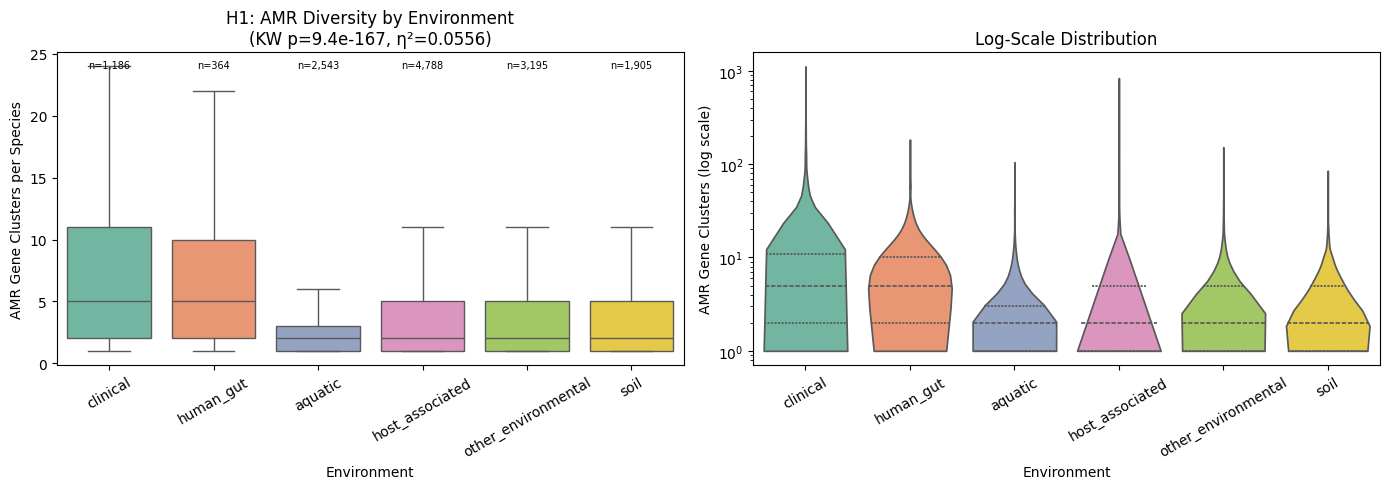

Saved to figures/h1_amr_by_environment.png


In [4]:
# Figure: AMR diversity by environment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot
ax = axes[0]
order = sp_env.groupby('species_environment')['n_amr_clusters'].median().sort_values(ascending=False).index
sns.boxplot(data=sp_env, x='species_environment', y='n_amr_clusters',
            order=order, ax=ax, showfliers=False, palette='Set2')
ax.set_xlabel('Environment')
ax.set_ylabel('AMR Gene Clusters per Species')
ax.set_title(f'H1: AMR Diversity by Environment\n(KW p={kw_p:.2g}, η²={eta_sq:.4f})')
ax.tick_params(axis='x', rotation=30)
for i, env in enumerate(order):
    n = len(sp_env[sp_env['species_environment'] == env])
    ax.text(i, ax.get_ylim()[1]*0.95, f'n={n:,}', ha='center', fontsize=7)

# Right: log scale for better visualization
ax = axes[1]
sns.violinplot(data=sp_env, x='species_environment', y='n_amr_clusters',
               order=order, ax=ax, palette='Set2', cut=0, inner='quartile')
ax.set_yscale('log')
ax.set_xlabel('Environment')
ax.set_ylabel('AMR Gene Clusters (log scale)')
ax.set_title('Log-Scale Distribution')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'h1_amr_by_environment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/h1_amr_by_environment.png')

## 2. H2: Core vs accessory AMR by environment

In [5]:
# Compare fraction of core vs accessory AMR across environments
print('=== H2: Core vs accessory AMR fraction by environment ===')

for env in envs:
    sub = sp_env[sp_env['species_environment'] == env]
    # Only species with >0 AMR clusters
    sub_amr = sub[sub['n_amr_clusters'] > 0]
    mean_pct_core = sub_amr['pct_core_amr'].mean()
    mean_pct_acc = sub_amr['pct_accessory_amr'].mean()
    print(f'  {env:25s}: N={len(sub_amr):5,}, core AMR={mean_pct_core:5.1f}%, '
          f'accessory AMR={mean_pct_acc:5.1f}%')

# Test: does core AMR fraction differ by environment?
groups_core = [sp_env[sp_env['species_environment'] == e]['pct_core_amr'].dropna().values for e in envs]
kw_core, p_core = stats.kruskal(*[g for g in groups_core if len(g) > 0])
eta_core = (kw_core - k + 1) / (sum(len(g) for g in groups_core) - k)
print(f'\nKruskal-Wallis (core AMR %): H={kw_core:.1f}, p={p_core:.4g}, η²={eta_core:.4f}')

=== H2: Core vs accessory AMR fraction by environment ===
  clinical                 : N=1,186, core AMR= 32.4%, accessory AMR= 67.6%
  human_gut                : N=  364, core AMR= 19.7%, accessory AMR= 80.3%
  host_associated          : N=4,788, core AMR= 49.7%, accessory AMR= 50.3%
  soil                     : N=1,905, core AMR= 57.1%, accessory AMR= 42.9%
  aquatic                  : N=2,543, core AMR= 54.4%, accessory AMR= 45.6%
  other_environmental      : N=3,195, core AMR= 40.4%, accessory AMR= 59.6%

Kruskal-Wallis (core AMR %): H=506.0, p=4.001e-107, η²=0.0359


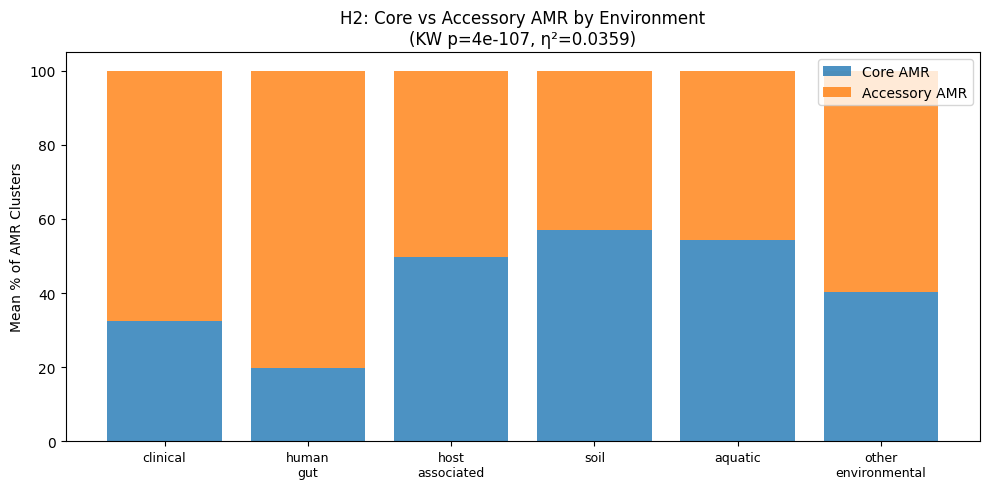

Saved to figures/h2_core_accessory_by_env.png


In [6]:
# Figure: core vs accessory by environment
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = sp_env[sp_env['n_amr_clusters'] > 0].copy()
order = ['clinical', 'human_gut', 'host_associated', 'soil', 'aquatic', 'other_environmental']

# Stacked bar: mean core vs accessory per environment
core_means = [plot_data[plot_data['species_environment'] == e]['pct_core_amr'].mean() for e in order]
acc_means = [plot_data[plot_data['species_environment'] == e]['pct_accessory_amr'].mean() for e in order]

x = range(len(order))
ax.bar(x, core_means, label='Core AMR', color='tab:blue', alpha=0.8)
ax.bar(x, acc_means, bottom=core_means, label='Accessory AMR', color='tab:orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([e.replace('_', '\n') for e in order], fontsize=9)
ax.set_ylabel('Mean % of AMR Clusters')
ax.set_title(f'H2: Core vs Accessory AMR by Environment\n(KW p={p_core:.2g}, η²={eta_core:.4f})')
ax.legend()
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'h2_core_accessory_by_env.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/h2_core_accessory_by_env.png')

## 3. H3: Mechanism enrichment by environment

In [7]:
# For each mechanism, test whether its fraction of AMR differs by environment
mechanisms = ['n_efflux', 'n_enzymatic', 'n_metal', 'n_target_mod']
mech_labels = ['Efflux', 'Enzymatic inactivation', 'Metal resistance', 'Target modification']

print('=== H3: Mechanism composition by environment ===')

mech_results = []
for mech_col, mech_label in zip(mechanisms, mech_labels):
    # Fraction of AMR that is this mechanism per species
    sp_env[f'frac_{mech_col}'] = sp_env[mech_col] / sp_env['n_amr_clusters']
    
    groups = [sp_env[sp_env['species_environment'] == e][f'frac_{mech_col}'].dropna().values for e in envs]
    groups = [g for g in groups if len(g) > 0]
    
    kw_stat, kw_p = stats.kruskal(*groups)
    eta = (kw_stat - len(groups) + 1) / (sum(len(g) for g in groups) - len(groups))
    
    mech_results.append({'mechanism': mech_label, 'kw_H': kw_stat, 'p_value': kw_p, 'eta_sq': eta})
    
    # Per-environment means
    env_means = {e: sp_env[sp_env['species_environment'] == e][f'frac_{mech_col}'].mean() * 100
                 for e in envs}
    means_str = ', '.join(f'{e[:4]}={v:.1f}%' for e, v in sorted(env_means.items(), key=lambda x: -x[1]))
    print(f'  {mech_label:30s}: H={kw_stat:7.1f}, p={kw_p:.4g}, η²={eta:.4f}  [{means_str}]')

mech_df = pd.DataFrame(mech_results)
_, q, _, _ = multipletests(mech_df['p_value'], method='fdr_bh')
mech_df['q_value'] = q
print(f'\nAfter BH-FDR correction:')
for _, row in mech_df.iterrows():
    sig = '***' if row['q_value'] < 0.001 else '**' if row['q_value'] < 0.01 else '*' if row['q_value'] < 0.05 else ''
    print(f'  {row["mechanism"]:30s}: q={row["q_value"]:.4g}, η²={row["eta_sq"]:.4f} {sig}')

=== H3: Mechanism composition by environment ===
  Efflux                        : H=  768.0, p=9.816e-164, η²=0.0546  [huma=7.0%, clin=6.1%, host=3.7%, othe=2.7%, soil=2.0%, aqua=1.1%]
  Enzymatic inactivation        : H=  266.0, p=1.978e-55, η²=0.0187  [host=44.1%, aqua=41.2%, soil=34.3%, othe=33.6%, clin=28.2%, huma=24.1%]
  Metal resistance              : H= 1498.4, p=0, η²=0.1069  [aqua=45.0%, soil=44.0%, othe=24.9%, clin=19.7%, host=12.7%, huma=6.1%]
  Target modification           : H= 1394.9, p=1.736e-299, η²=0.0995  [huma=43.6%, clin=27.5%, othe=25.1%, host=22.8%, soil=10.1%, aqua=6.2%]

After BH-FDR correction:
  Efflux                        : q=1.309e-163, η²=0.0546 ***
  Enzymatic inactivation        : q=1.978e-55, η²=0.0187 ***
  Metal resistance              : q=0, η²=0.1069 ***
  Target modification           : q=3.472e-299, η²=0.0995 ***


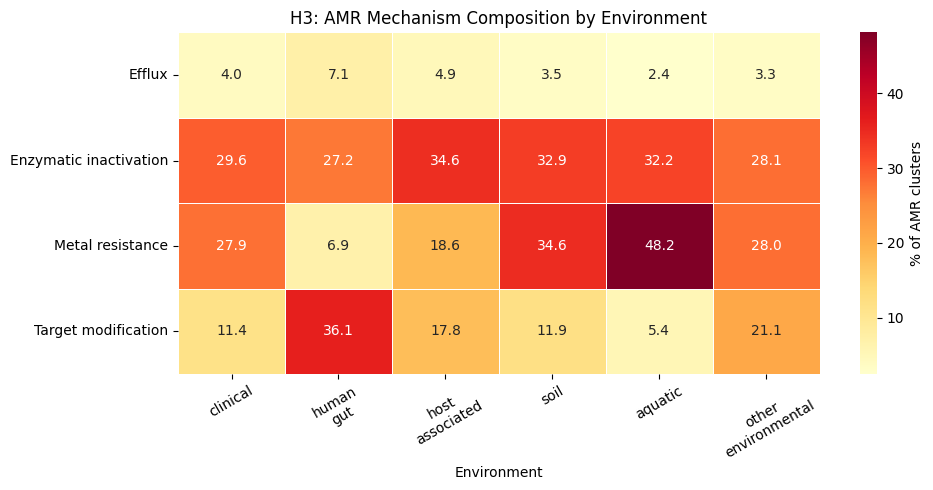

Saved to figures/h3_mechanism_by_environment.png


In [8]:
# Mechanism × environment heatmap
fig, ax = plt.subplots(figsize=(10, 5))

heatmap_data = []
for mech_col, mech_label in zip(mechanisms, mech_labels):
    for env in envs:
        sub = sp_env[sp_env['species_environment'] == env]
        mean_frac = sub[mech_col].sum() / sub['n_amr_clusters'].sum() * 100
        heatmap_data.append({'Mechanism': mech_label, 'Environment': env, 'Fraction (%)': mean_frac})

hm_df = pd.DataFrame(heatmap_data)
hm_pivot = hm_df.pivot(index='Mechanism', columns='Environment', values='Fraction (%)')
hm_pivot = hm_pivot[envs]  # order columns

sns.heatmap(hm_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of AMR clusters'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('H3: AMR Mechanism Composition by Environment')
ax.set_ylabel('')
ax.set_xticklabels([e.replace('_', '\n') for e in envs], rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'h3_mechanism_by_environment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/h3_mechanism_by_environment.png')

## 4. Phylogenetic control

In [9]:
# Stratified analysis within major phyla
# Does the environment effect hold after controlling for phylogeny?

major_phyla = sp_env['phylum'].value_counts().head(6).index.tolist()
print(f'=== Phylogenetic control: stratified by phylum ===')
print(f'Major phyla: {major_phyla}')

strat_results = []
for phylum in major_phyla:
    phy_data = sp_env[sp_env['phylum'] == phylum]
    phy_envs = phy_data['species_environment'].value_counts()
    testable_envs = phy_envs[phy_envs >= 10].index.tolist()
    
    if len(testable_envs) < 2:
        print(f'  {phylum:40s}: <2 environments with N>=10, skipping')
        continue
    
    groups = [phy_data[phy_data['species_environment'] == e]['n_amr_clusters'].values 
              for e in testable_envs]
    kw_stat, kw_p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eta = (kw_stat - len(groups) + 1) / (n - len(groups)) if n > len(groups) else 0
    
    strat_results.append({'phylum': phylum, 'n_species': n, 'n_envs': len(testable_envs),
                          'kw_H': kw_stat, 'p_value': kw_p, 'eta_sq': eta})
    
    env_summary = ', '.join(f'{e[:4]}={len(phy_data[phy_data["species_environment"]==e])}' 
                            for e in testable_envs)
    sig = '*' if kw_p < 0.05 else ''
    print(f'  {phylum:40s}: KW p={kw_p:.4g}, η²={eta:.4f} {sig} [{env_summary}]')

strat_df = pd.DataFrame(strat_results)
if len(strat_df) > 0:
    _, q, _, _ = multipletests(strat_df['p_value'], method='fdr_bh')
    strat_df['q_value'] = q
    print(f'\nPhyla with FDR-significant environment effect: '
          f'{(strat_df["q_value"] < 0.05).sum()}/{len(strat_df)}')

=== Phylogenetic control: stratified by phylum ===
Major phyla: ['p__Pseudomonadota', 'p__Bacillota_A', 'p__Actinomycetota', 'p__Bacteroidota', 'p__Bacillota', 'p__Chloroflexota']
  p__Pseudomonadota                       : KW p=6.105e-69, η²=0.0689 * [host=1631, aqua=1330, othe=765, soil=587, clin=371, huma=24]
  p__Bacillota_A                          : KW p=1.402e-32, η²=0.0694 * [host=1171, othe=734, huma=176, clin=111, aqua=19, soil=18]
  p__Actinomycetota                       : KW p=2.072e-23, η²=0.0624 * [host=580, soil=452, othe=308, clin=284, aqua=123, huma=39]
  p__Bacteroidota                         : KW p=8.487e-49, η²=0.1302 * [host=637, othe=436, aqua=392, soil=124, clin=113, huma=72]
  p__Bacillota                            : KW p=2.672e-07, η²=0.0255 * [othe=453, host=403, clin=238, soil=141, aqua=65, huma=30]
  p__Chloroflexota                        : KW p=0.5943, η²=-0.0065  [aqua=55, othe=53, soil=40, host=27]

Phyla with FDR-significant environment effect: 5/6


In [10]:
# Family-level control: ANOVA-like approach
# For each family with species in >=2 environments, test environment effect
family_env = sp_env.groupby(['family', 'species_environment']).size().reset_index(name='n')
family_multi = family_env.groupby('family').filter(lambda x: len(x) >= 2 and (x['n'] >= 5).sum() >= 2)
families_testable = family_multi['family'].unique()

print(f'Families with species in >=2 environments (N>=5 each): {len(families_testable)}')

fam_results = []
for fam in families_testable:
    fam_data = sp_env[sp_env['family'] == fam]
    fam_envs = fam_data.groupby('species_environment').filter(lambda x: len(x) >= 5)
    testable = fam_envs['species_environment'].unique()
    if len(testable) < 2:
        continue
    groups = [fam_envs[fam_envs['species_environment'] == e]['n_amr_clusters'].values for e in testable]
    if any(len(g) < 5 for g in groups):
        continue
    kw_stat, kw_p = stats.kruskal(*groups)
    fam_results.append({'family': fam, 'p_value': kw_p, 'n_envs': len(testable),
                        'n_species': sum(len(g) for g in groups)})

fam_df = pd.DataFrame(fam_results)
if len(fam_df) > 0:
    _, q, _, _ = multipletests(fam_df['p_value'], method='fdr_bh')
    fam_df['q_value'] = q
    n_sig = (fam_df['q_value'] < 0.05).sum()
    print(f'Families tested: {len(fam_df)}, FDR significant: {n_sig} ({n_sig/len(fam_df)*100:.0f}%)')
    if n_sig > 0:
        print(f'\nTop significant families:')
        for _, row in fam_df[fam_df['q_value'] < 0.05].nsmallest(10, 'q_value').iterrows():
            print(f'  {row["family"]:40s}: q={row["q_value"]:.4g}, {row["n_species"]} species in {row["n_envs"]} envs')

Families with species in >=2 environments (N>=5 each): 141


Families tested: 141, FDR significant: 20 (14%)

Top significant families:
  f__Enterobacteriaceae                   : q=3.02e-21, 415 species in 6 envs
  f__Bacteroidaceae                       : q=1.262e-17, 404 species in 4 envs
  f__Lachnospiraceae                      : q=2.453e-12, 790 species in 4 envs
  f__Pseudomonadaceae                     : q=3.851e-12, 463 species in 5 envs
  f__Ruminococcaceae                      : q=2.599e-07, 199 species in 4 envs
  f__Acutalibacteraceae                   : q=3.705e-06, 210 species in 3 envs
  f__Burkholderiaceae                     : q=9.895e-06, 252 species in 5 envs
  f__Moraxellaceae                        : q=0.0001307, 152 species in 4 envs
  f__Oscillospiraceae                     : q=0.0002761, 243 species in 3 envs
  f__Xanthomonadaceae                     : q=0.0002761, 193 species in 5 envs


## 5. Sensitivity analysis: majority threshold

In [11]:
# Save original H1 stats before the loop overwrites kw_p
h1_kw_stat, h1_kw_p, h1_eta_sq = kw_stat, kw_p, eta_sq

# Does the H1 result hold at stricter majority thresholds?
print('=== Sensitivity: majority vote threshold ===')
for threshold in [0.5, 0.6, 0.75, 0.9]:
    strict = sp_env[sp_env['majority_frac'] >= threshold]
    if strict['species_environment'].nunique() < 3:
        print(f'  >={threshold*100:.0f}% majority: {len(strict)} species, too few environments')
        continue
    
    groups = [strict[strict['species_environment'] == e]['n_amr_clusters'].values 
              for e in envs if len(strict[strict['species_environment'] == e]) >= 5]
    if len(groups) < 2:
        print(f'  >={threshold*100:.0f}% majority: {len(strict)} species, <2 testable environments')
        continue
    
    kw_stat, kw_p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    eta = (kw_stat - len(groups) + 1) / (n - len(groups))
    print(f'  >={threshold*100:.0f}% majority: N={len(strict):,}, KW p={kw_p:.4g}, η²={eta:.4f}')

=== Sensitivity: majority vote threshold ===
  >=50% majority: N=13,290, KW p=1.815e-139, η²=0.0490
  >=60% majority: N=10,885, KW p=4.607e-127, η²=0.0545
  >=75% majority: N=9,231, KW p=3.769e-107, η²=0.0543
  >=90% majority: N=7,988, KW p=4.497e-75, η²=0.0441


## 6. Save and summarize

In [12]:
# Save results
pw_df.to_csv(os.path.join(DATA, 'pairwise_environment_comparisons.csv'), index=False)
mech_df.to_csv(os.path.join(DATA, 'mechanism_by_environment.csv'), index=False)
if len(strat_df) > 0:
    strat_df.to_csv(os.path.join(DATA, 'stratified_phylum_results.csv'), index=False)
if len(fam_df) > 0:
    fam_df.to_csv(os.path.join(DATA, 'family_level_environment_test.csv'), index=False)

print(f'=== NB02 Summary ===')
print(f'H1 (AMR diversity by environment): KW p={h1_kw_p:.4g}, η²={h1_eta_sq:.4f}')
print(f'H2 (core vs accessory): KW p={p_core:.4g}, η²={eta_core:.4f}')
print(f'H3 (mechanism by environment):')
for _, row in mech_df.iterrows():
    print(f'  {row["mechanism"]:30s}: q={row["q_value"]:.4g}, η²={row["eta_sq"]:.4f}')
if len(strat_df) > 0:
    print(f'Phylogenetic control: {(strat_df["q_value"] < 0.05).sum()}/{len(strat_df)} phyla show '
          f'within-phylum environment effect')
if len(fam_df) > 0:
    print(f'Family-level control: {(fam_df["q_value"] < 0.05).sum()}/{len(fam_df)} families show '
          f'within-family environment effect')

=== NB02 Summary ===
H1 (AMR diversity by environment): KW p=1.958e-05, η²=0.0556
H2 (core vs accessory): KW p=4.001e-107, η²=0.0359
H3 (mechanism by environment):
  Efflux                        : q=1.309e-163, η²=0.0546
  Enzymatic inactivation        : q=1.978e-55, η²=0.0187
  Metal resistance              : q=0, η²=0.1069
  Target modification           : q=3.472e-299, η²=0.0995
Phylogenetic control: 5/6 phyla show within-phylum environment effect
Family-level control: 20/141 families show within-family environment effect
